<a href="https://colab.research.google.com/github/haujla2391/CSCI-4170/blob/main/CSCI4170_hw5_task3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task 3

## 1.

### Numpy scaled dot product attention functions

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch.nn as nn
import torch
import torch.nn.functional as F
from datasets import load_dataset
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader

In [2]:
def softmax(att):
  e_att = np.exp(att)
  sum_e_att = np.sum(e_att, axis=-1, keepdims=True)
  return e_att/sum_e_att

In [3]:
def scaledDotProduct(Q, K, V):
  qk = Q @ K.T
  d_k = K.shape[-1]
  att = qk / (d_k**0.5)
  return softmax(att) @ V

## 2.

### Model definition (GRU to GRU model)

In [4]:
device = "cuda" if torch.cuda.is_available() else "cpu"

In [14]:
# Torch version of scaled dot product
def torch_sdp(Q, K, V):
  d_k = Q.size(-1)
  scores = torch.matmul(Q, K.transpose(-2, -1)) / (d_k ** 0.5)
  return torch.matmul(F.softmax(scores, dim=-1), V)

In [12]:
class EncoderGRU(nn.Module):
  def __init__(self, vocab_size, embed_dim, hidden_size, num_layers):
    super().__init__()

    self.hidden_size = hidden_size
    self.num_layers = num_layers

    self.gru = nn.GRU(embed_dim, hidden_size, num_layers, batch_first=True)

    self.embed = nn.Embedding(vocab_size, embed_dim)

  def forward(self, x):
    x = self.embed(x)

    h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(device)   # hidden state before first input (0)

    out, hidden = self.gru(x, h0)
    return out, hidden

In [13]:
class DecoderGRU(nn.Module):
  def __init__(self, vocab_size, embed_dim, hidden_size, num_layers):
    super().__init__()

    self.embed = nn.Embedding(vocab_size, embed_dim)

    self.gru = nn.GRU(embed_dim, hidden_size, num_layers, batch_first=True)
    self.fc = nn.Linear(hidden_size * 2, vocab_size)

  def forward(self, x, hidden, encoder_outs):
    x = self.embed(x)
    out, hidden = self.gru(x, hidden)

    context = torch_sdp(out, encoder_outs, encoder_outs)

    pred = torch.cat((out, context), dim=-1)   # concatenate(stack) along last dimension (hidden dim)
    logits = self.fc(pred)

    return logits, hidden

## 3.

### Load subset of Tatoeba

In [5]:
# 1. Download and unzip the English-French Tatoeba data
!wget -q https://www.manythings.org/anki/fra-eng.zip
!rm -rf fra-eng          # Remove old folder if it exists
!unzip -q fra-eng.zip -d fra-eng

df = pd.read_csv('fra-eng/fra.txt',
                 sep='\t',
                 header=None,
                 names=['english', 'french'],
                 encoding='utf-8')

print(df.head())

        english                                             french
Go.        Va !  CC-BY 2.0 (France) Attribution: tatoeba.org #2...
Go.     Marche.  CC-BY 2.0 (France) Attribution: tatoeba.org #2...
Go.  En route !  CC-BY 2.0 (France) Attribution: tatoeba.org #2...
Go.     Bouge !  CC-BY 2.0 (France) Attribution: tatoeba.org #2...
Hi.     Salut !  CC-BY 2.0 (France) Attribution: tatoeba.org #5...


In [6]:
# Define Special Tokens and Vocab Class ---
import re

SOS_TOKEN = 0
EOS_TOKEN = 1
PAD_TOKEN = 2
UNK_TOKEN = 3

class Vocab:
    def __init__(self):
        self.word2idx = {'<SOS>': SOS_TOKEN, '<EOS>': EOS_TOKEN, '<PAD>': PAD_TOKEN, '<UNK>': UNK_TOKEN}
        self.idx2word = {SOS_TOKEN: '<SOS>', EOS_TOKEN: '<EOS>', PAD_TOKEN: '<PAD>', UNK_TOKEN: '<UNK>'}
        self.word_count = {}
        self.n_words = 4  # Start with SOS, EOS, PAD, UNK

    def add_sentence(self, sentence):
        for word in self.tokenize(sentence):
            self.add_word(word)

    def add_word(self, word):
        if word not in self.word2idx:
            self.word2idx[word] = self.n_words
            self.idx2word[self.n_words] = word
            self.word_count[word] = 1
            self.n_words += 1
        else:
            self.word_count[word] += 1

    def tokenize(self, text):
        # Improved tokenization: remove punctuation, convert to lowercase, and split by space
        text = re.sub(r'[^À-῿Ⰰ-퟿가-힣぀-ヿ一-鿿豈-﫿a-zA-Z0-9　-〿＀-￯ -~]', ' ', text) # Keep common unicode ranges, alphanumeric, and basic punctuation
        text = re.sub(r' +', ' ', text) # Replace multiple spaces with a single space
        tokens = [word.lower().strip() for word in text.split(' ') if word.strip() != '']
        return tokens

In [7]:
class TranslationDataset(Dataset):
    def __init__(self, dataframe, src_vocab, tgt_vocab):
        self.dataframe = dataframe
        self.src_vocab = src_vocab
        self.tgt_vocab = tgt_vocab

    def __len__(self):
        return len(self.dataframe)

    def encode(self, sentence, vocab):
        tokens = vocab.tokenize(sentence)
        indexed_tokens = [vocab.word2idx.get(word, UNK_TOKEN) for word in tokens]
        return [SOS_TOKEN] + indexed_tokens + [EOS_TOKEN]

    def __getitem__(self, idx):
        src = self.dataframe.iloc[idx]['english']
        tgt = self.dataframe.iloc[idx]['french']

        X = self.encode(src, self.src_vocab)
        y = self.encode(tgt, self.tgt_vocab)

        return torch.tensor(X, dtype=torch.long), torch.tensor(y, dtype=torch.long)

In [8]:
subset_df = df.sample(n=10000, random_state=42)

train_df, test_df = train_test_split(
    subset_df,
    test_size=0.1,           # 10% for test, 90% for train
    random_state=42,
    shuffle=True
)

print(f"Train set: {len(train_df):,} sentences")
print(f"Test set : {len(test_df):,} sentences")

Train set: 9,000 sentences
Test set : 1,000 sentences


In [9]:
# Build vocabularies
english_vocab = Vocab()
french_vocab = Vocab()

for _, row in subset_df.iterrows():
    english_vocab.add_sentence(row['english'])
    french_vocab.add_sentence(row['french'])

print(f"English Vocabulary Size: {english_vocab.n_words}")
print(f"French Vocabulary Size: {french_vocab.n_words}")

English Vocabulary Size: 9676
French Vocabulary Size: 20364


In [10]:
train_dataset = TranslationDataset(train_df, english_vocab, french_vocab)
test_dataset = TranslationDataset(test_df, english_vocab, french_vocab)

In [15]:
embed_dim = 32
hidden_size = 64
num_layers = 1

encoder = EncoderGRU(english_vocab.n_words, embed_dim, hidden_size, num_layers).to(device)
decoder = DecoderGRU(french_vocab.n_words, embed_dim, hidden_size, num_layers).to(device)

### Train phase

In [16]:
num_epochs = 80
batch_size = 32
lr = 0.00001
weight_decay = 0.00001

In [17]:
# Collate function for padding
def collate_fn(batch):
    # Sort batch by source sentence length for efficient padding (optional but good practice)
    batch.sort(key=lambda x: len(x[0]), reverse=True)

    src_batch, tgt_batch = zip(*batch)

    # Pad source sequences
    src_lengths = [len(seq) for seq in src_batch]
    src_padded = torch.full((len(src_batch), max(src_lengths)), PAD_TOKEN, dtype=torch.long)
    for i, seq in enumerate(src_batch):
        src_padded[i, :len(seq)] = seq

    # Pad target sequences
    tgt_lengths = [len(seq) for seq in tgt_batch]
    tgt_padded = torch.full((len(tgt_batch), max(tgt_lengths)), PAD_TOKEN, dtype=torch.long)
    for i, seq in enumerate(tgt_batch):
        tgt_padded[i, :len(seq)] = seq

    return src_padded, tgt_padded

# DataLoaders using the custom Dataset and collate_fn
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, collate_fn=collate_fn)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_fn)

In [ ]:
criterion = torch.nn.CrossEntropyLoss(ignore_index=PAD_TOKEN)
encoder_optimizer = torch.optim.Adam(encoder.parameters(), lr=lr, weight_decay=weight_decay)
decoder_optimizer = torch.optim.Adam(decoder.parameters(), lr=lr, weight_decay=weight_decay)

In [ ]:
def train(dataloader, encoder, decoder, optim_e, optim_d, vocab_size):
  encoder.train()
  decoder.train()

  total_loss = 0.0

  for i, (X, y) in enumerate(dataloader):
    X, y = X.to(device), y.to(device)

    out_enc, h_enc = encoder(X)

    decoder_inputs = y[:, :-1]
    decoder_targets = y[:, 1:]

    logits, h_dec = decoder(decoder_inputs, h_enc, out_enc)
    loss = criterion(logits.reshape(-1, vocab_size), decoder_targets.reshape(-1))

    optim_e.zero_grad()
    optim_d.zero_grad()

    loss.backward()

    optim_e.step()
    optim_d.step()

    total_loss += loss.item()

    if i % 50 == 0:
      print(f"Batch {i}/{len(dataloader)} Loss: {loss.item():.4f}")

  return total_loss / len(dataloader)

In [ ]:
train_losses = []
for epoch in range(num_epochs):
  print("Epoch: ", epoch+1)
  train_losses.append(train(train_loader, encoder, decoder, encoder_optimizer, decoder_optimizer, french_vocab.n_words))

Epoch:  1
Batch 0/282 Loss: 9.9956
Batch 50/282 Loss: 9.9564
Batch 100/282 Loss: 9.9475
Batch 150/282 Loss: 9.9189
Batch 200/282 Loss: 9.8893
Batch 250/282 Loss: 9.8702
Epoch:  2
Batch 0/282 Loss: 9.8372
Batch 50/282 Loss: 9.8226
Batch 100/282 Loss: 9.7954
Batch 150/282 Loss: 9.7706
Batch 200/282 Loss: 9.7354
Batch 250/282 Loss: 9.7188
Epoch:  3
Batch 0/282 Loss: 9.6978
Batch 50/282 Loss: 9.6694
Batch 100/282 Loss: 9.5998
Batch 150/282 Loss: 9.5562
Batch 200/282 Loss: 9.5036
Batch 250/282 Loss: 9.4487
Epoch:  4
Batch 0/282 Loss: 9.4984
Batch 50/282 Loss: 9.4144
Batch 100/282 Loss: 9.3165
Batch 150/282 Loss: 9.2356
Batch 200/282 Loss: 9.2419
Batch 250/282 Loss: 9.1194
Epoch:  5
Batch 0/282 Loss: 9.1043
Batch 50/282 Loss: 9.0930
Batch 100/282 Loss: 8.9710
Batch 150/282 Loss: 8.8624
Batch 200/282 Loss: 8.6934
Batch 250/282 Loss: 8.6818
Epoch:  6
Batch 0/282 Loss: 8.5332
Batch 50/282 Loss: 8.5467
Batch 100/282 Loss: 8.3237
Batch 150/282 Loss: 8.2349
Batch 200/282 Loss: 8.2374
Batch 250/282

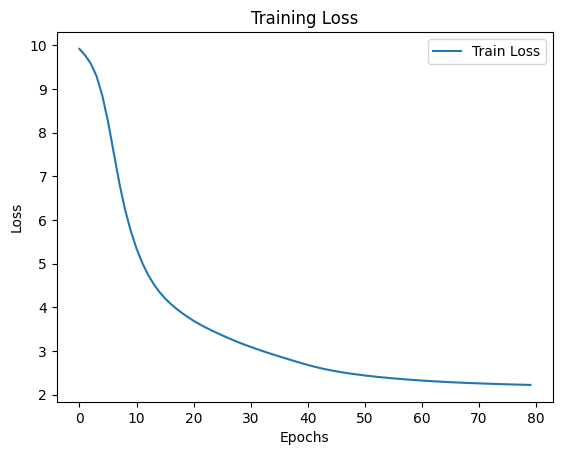

In [ ]:
plt.plot(train_losses, label='Train Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Training Loss')
plt.show()

### Test phase

In [ ]:
from nltk.translate.bleu_score import corpus_bleu

def evaluate_bleu(encoder, decoder, dataloader, tgt_vocab, max_len=20):
    encoder.eval()
    decoder.eval()

    references = []
    hypotheses = []

    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)

            # Encoder forward
            enc_out, h_enc = encoder(X)

            # Start decoding with SOS
            decoder_input = torch.full((X.size(0), 1), SOS_TOKEN).to(device)
            hidden = h_enc

            preds = []

            for _ in range(max_len):
                logits, hidden = decoder(decoder_input, hidden, enc_out)

                # Take last token prediction
                next_token = logits[:, -1, :].argmax(dim=-1, keepdim=True)

                preds.append(next_token)
                decoder_input = next_token

            preds = torch.cat(preds, dim=1)

            # Convert indices → words
            for i in range(X.size(0)):
                ref = [
                    tgt_vocab.idx2word[idx.item()]
                    for idx in y[i]
                    if idx.item() not in [PAD_TOKEN, SOS_TOKEN, EOS_TOKEN]
                ]

                hyp = [
                    tgt_vocab.idx2word[idx.item()]
                    for idx in preds[i]
                    if idx.item() not in [PAD_TOKEN, SOS_TOKEN, EOS_TOKEN]
                ]

                if len(hyp) > 0 and len(ref) > 0:
                    references.append([ref])   # list of references
                    hypotheses.append(hyp)

    return corpus_bleu(references, hypotheses)

In [ ]:
bleu_score = evaluate_bleu(encoder, decoder, test_loader, french_vocab)
print(f"\nTest BLEU Score: {bleu_score:.4f}")


Test BLEU Score: 0.4468


Not great, but good for a smaller model such as mine.

## 4.

In [45]:
NUM_ENCODER_LAYERS = 2
NUM_DECODER_LAYERS = 2
NUM_HEADS = 2
EMBED_DIM = 64
FF_DIM = 128
MAX_LEN = 100

### Sinusoidal Positional Encoding


In [46]:
class PositionalEncoding(nn.Module):
  def __init__(self, d_model, max_len = MAX_LEN):
    super().__init__()

    pe = torch.zeros(max_len, d_model)    # num words by embedding dim

    position = torch.arange(0, max_len).unsqueeze(1)
    div_term = torch.exp(
          (torch.arange(0, d_model, 2)) * (-np.log(10000)/d_model)
        )

    pe[:, 0::2] = torch.sin(position * div_term)
    pe[:, 1::2] = torch.cos(position * div_term)

    self.pe = pe.unsqueeze(0)

  def forward(self, x):
    return x + self.pe[:, :x.size(1)].to(x.device)

### Scaled dot product attention with mask

In [47]:
def torch_sdp(Q, K, V, mask=None):
  d_k = Q.size(-1)
  scores = torch.matmul(Q, K.transpose(-2, -1)) / (d_k ** 0.5)

  if mask is not None:
    scores = scores.masked_fill(mask==0, -1e9)

  return torch.matmul(F.softmax(scores, dim=-1), V)

### Multi-head Attention

In [48]:
class MultiHeadAttention(nn.Module):
  def __init__(self, embed_dim, num_heads=NUM_HEADS):
    super().__init__()

    self.num_heads = num_heads
    self.head_dim = embed_dim // num_heads

    self.q_linear = nn.Linear(embed_dim, embed_dim)
    self.k_linear = nn.Linear(embed_dim, embed_dim)
    self.v_linear = nn.Linear(embed_dim, embed_dim)

    self.out = nn.Linear(embed_dim, embed_dim)

  def forward(self, Q, K, V, mask=None):
    B = Q.size(0)

    Q = self.q_linear(Q)
    K = self.k_linear(K)
    V = self.v_linear(V)

    Q = Q.view(B, -1, self.num_heads, self.head_dim).transpose(1, 2)
    K = K.view(B, -1, self.num_heads, self.head_dim).transpose(1, 2)
    V = V.view(B, -1, self.num_heads, self.head_dim).transpose(1, 2)

    attn = torch_sdp(Q, K, V, mask)

    attn = attn.transpose(2, 1).contiguous().view(B, -1, self.num_heads * self.head_dim)
    return self.out(attn)

### Feed Forward Network

In [49]:
class FeedForward(nn.Module):
  def __init__(self, embed_dim, ff_dim):
    super().__init__()
    self.net = nn.Sequential(
        nn.Linear(embed_dim, ff_dim),
        nn.ReLU(),
        nn.Linear(ff_dim, embed_dim)
    )

  def forward(self, x):
    return self.net(x)

### Encoder

In [50]:
class EncoderLayer(nn.Module):
  def __init__(self, embed_dim, num_heads, ff_dim):
    super().__init__()

    self.attn = MultiHeadAttention(embed_dim, num_heads)

    self.ff = FeedForward(embed_dim, ff_dim)

    self.norm1 = nn.LayerNorm(embed_dim)
    self.norm2 = nn.LayerNorm(embed_dim)

  def forward(self, x, mask=None):
    attn = self.attn(x, x, x, mask)
    x = self.norm1(x + attn)

    ff = self.ff(x)
    x = self.norm2(x + ff)
    return x

### Decoder

In [51]:
class DecoderLayer(nn.Module):
  def __init__(self, embed_dim, num_heads, ff_dim):
    super().__init__()

    self.self_attn = MultiHeadAttention(embed_dim, num_heads)
    self.cross_attn = MultiHeadAttention(embed_dim, num_heads)
    self.ff = FeedForward(embed_dim, ff_dim)

    self.norm1 = nn.LayerNorm(embed_dim)
    self.norm2 = nn.LayerNorm(embed_dim)
    self.norm3 = nn.LayerNorm(embed_dim)

  def forward(self, x, enc_out, tgt_mask, src_mask):
    x = self.norm1(x + self.self_attn(x, x, x, tgt_mask))
    x = self.norm2(x + self.cross_attn(x, enc_out, enc_out, src_mask))
    x = self.norm3(x + self.ff(x))
    return x

### Transformer model

In [52]:
class Transformer(nn.Module):
  def __init__(self, src_vocab, tgt_vocab):
    super().__init__()

    self.src_embed = nn.Embedding(src_vocab, EMBED_DIM)
    self.tgt_embed = nn.Embedding(tgt_vocab, EMBED_DIM)

    self.pos = PositionalEncoding(EMBED_DIM)

    self.enc_layers = nn.ModuleList([
        EncoderLayer(EMBED_DIM, NUM_HEADS, FF_DIM)
        for _ in range(NUM_ENCODER_LAYERS)
        ])

    self.dec_layers = nn.ModuleList([
        DecoderLayer(EMBED_DIM, NUM_HEADS, FF_DIM)
        for _ in range(NUM_DECODER_LAYERS)
    ])

    self.fc = nn.Linear(EMBED_DIM, tgt_vocab)

  def forward(self, src, tgt, src_mask, tgt_mask):
    src = self.pos(self.src_embed(src))
    tgt = self.pos(self.tgt_embed(tgt))

    for layer in self.enc_layers:
      src = layer(src, src_mask)

    for layer in self.dec_layers:
      tgt = layer(tgt, src, tgt_mask, src_mask)

    return self.fc(tgt)

### Masking

In [53]:
def generate_square_subsequent_mask(sz):
  return torch.tril(torch.ones(sz, sz)).bool().to(device)

### Train phase

In [54]:
num_epochs = 50
lr = 0.00001

In [55]:
model = Transformer(english_vocab.n_words, french_vocab.n_words).to(device)
criterion = nn.CrossEntropyLoss(ignore_index=PAD_TOKEN)
optimizer = torch.optim.Adam(model.parameters(), lr = lr)

In [56]:
def create_src_mask(src):
    # (batch, 1, 1, src_len)
    return (src != PAD_TOKEN).unsqueeze(1).unsqueeze(2)

def create_tgt_mask(tgt):
    # padding mask
    tgt_pad_mask = (tgt != PAD_TOKEN).unsqueeze(1).unsqueeze(2)

    # causal mask (no peeking ahead)
    seq_len = tgt.size(1)
    tgt_sub_mask = torch.tril(torch.ones((seq_len, seq_len))).bool().to(tgt.device)

    return tgt_pad_mask & tgt_sub_mask

In [57]:
def train_transformer(dataloader, model, optimizer, criterion, tgt_vocab_size):
    model.train()
    total_loss = 0

    for i, (src, tgt) in enumerate(dataloader):
        src, tgt = src.to(device), tgt.to(device)

        # Shift target
        tgt_input = tgt[:, :-1]
        tgt_output = tgt[:, 1:]

        # Masks
        src_mask = create_src_mask(src)
        tgt_mask = create_tgt_mask(tgt_input)

        # Forward
        logits = model(src, tgt_input, src_mask, tgt_mask)

        loss = criterion(
            logits.reshape(-1, tgt_vocab_size),
            tgt_output.reshape(-1)
        )

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        if i % 50 == 0:
            print(f"Batch {i}/{len(dataloader)} Loss: {loss.item():.4f}")

    return total_loss / len(dataloader)

In [59]:
train_losses = []
for epoch in range(num_epochs):
  print(f"\nEpoch {epoch+1}")
  loss = train_transformer(train_loader, model, optimizer, criterion, french_vocab.n_words)
  train_losses.append(loss)


Epoch 1
Batch 0/282 Loss: 10.0959
Batch 50/282 Loss: 9.9055
Batch 100/282 Loss: 9.6795
Batch 150/282 Loss: 9.5562
Batch 200/282 Loss: 9.3550
Batch 250/282 Loss: 9.1407

Epoch 2
Batch 0/282 Loss: 9.0520
Batch 50/282 Loss: 8.9321
Batch 100/282 Loss: 8.7588
Batch 150/282 Loss: 8.6300
Batch 200/282 Loss: 8.5596
Batch 250/282 Loss: 8.4295

Epoch 3
Batch 0/282 Loss: 8.3392
Batch 50/282 Loss: 8.2476
Batch 100/282 Loss: 8.1980
Batch 150/282 Loss: 8.0574
Batch 200/282 Loss: 7.9223
Batch 250/282 Loss: 7.8496

Epoch 4
Batch 0/282 Loss: 7.7385
Batch 50/282 Loss: 7.6856
Batch 100/282 Loss: 7.6016
Batch 150/282 Loss: 7.5668
Batch 200/282 Loss: 7.4369
Batch 250/282 Loss: 7.2657

Epoch 5
Batch 0/282 Loss: 7.2417
Batch 50/282 Loss: 7.1575
Batch 100/282 Loss: 7.1486
Batch 150/282 Loss: 7.0190
Batch 200/282 Loss: 6.8681
Batch 250/282 Loss: 6.7631

Epoch 6
Batch 0/282 Loss: 6.7840
Batch 50/282 Loss: 6.7194
Batch 100/282 Loss: 6.6003
Batch 150/282 Loss: 6.6162
Batch 200/282 Loss: 6.4278
Batch 250/282 Loss

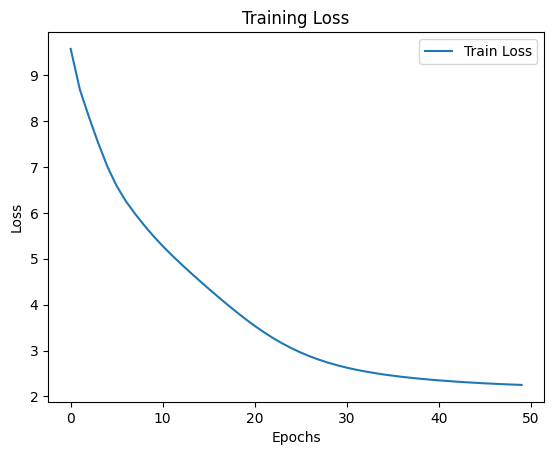

In [60]:
plt.plot(train_losses, label='Train Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Training Loss')
plt.show()

### Test phase

In [61]:
def greedy_decode(model, src, max_len=20):
    model.eval()

    src = src.to(device)
    src_mask = create_src_mask(src)

    # Start with SOS
    tgt = torch.full((src.size(0), 1), SOS_TOKEN).to(device)

    for _ in range(max_len):
        tgt_mask = create_tgt_mask(tgt)

        logits = model(src, tgt, src_mask, tgt_mask)

        next_token = logits[:, -1, :].argmax(dim=-1, keepdim=True)

        tgt = torch.cat([tgt, next_token], dim=1)

    return tgt

In [62]:
from nltk.translate.bleu_score import corpus_bleu

def evaluate_bleu_transformer(model, dataloader, tgt_vocab):
    model.eval()

    references = []
    hypotheses = []

    with torch.no_grad():
        for src, tgt in dataloader:
            src, tgt = src.to(device), tgt.to(device)

            preds = greedy_decode(model, src)

            for i in range(src.size(0)):
                ref = [
                    tgt_vocab.idx2word[idx.item()]
                    for idx in tgt[i]
                    if idx.item() not in [PAD_TOKEN, SOS_TOKEN, EOS_TOKEN]
                ]

                hyp = [
                    tgt_vocab.idx2word[idx.item()]
                    for idx in preds[i]
                    if idx.item() not in [PAD_TOKEN, SOS_TOKEN, EOS_TOKEN]
                ]

                if len(ref) > 0 and len(hyp) > 0:
                    references.append([ref])
                    hypotheses.append(hyp)

    return corpus_bleu(references, hypotheses)

In [63]:
bleu = evaluate_bleu_transformer(model, test_loader, french_vocab)
print(f"Transformer BLEU: {bleu:.4f}")

Transformer BLEU: 0.4083


This is pretty good BLEU score, the other Seq2Seq varied a lot when changing the number of epochs and almost seemed random. It would have a score of 0.20 and then 0.40 and then back down even though the number of epochs increased. The transformer consistently gets 0.40, meaning it is much better at this task. It is better because it has both self attention and cross attention, allowing it to predict the next word efficiently.